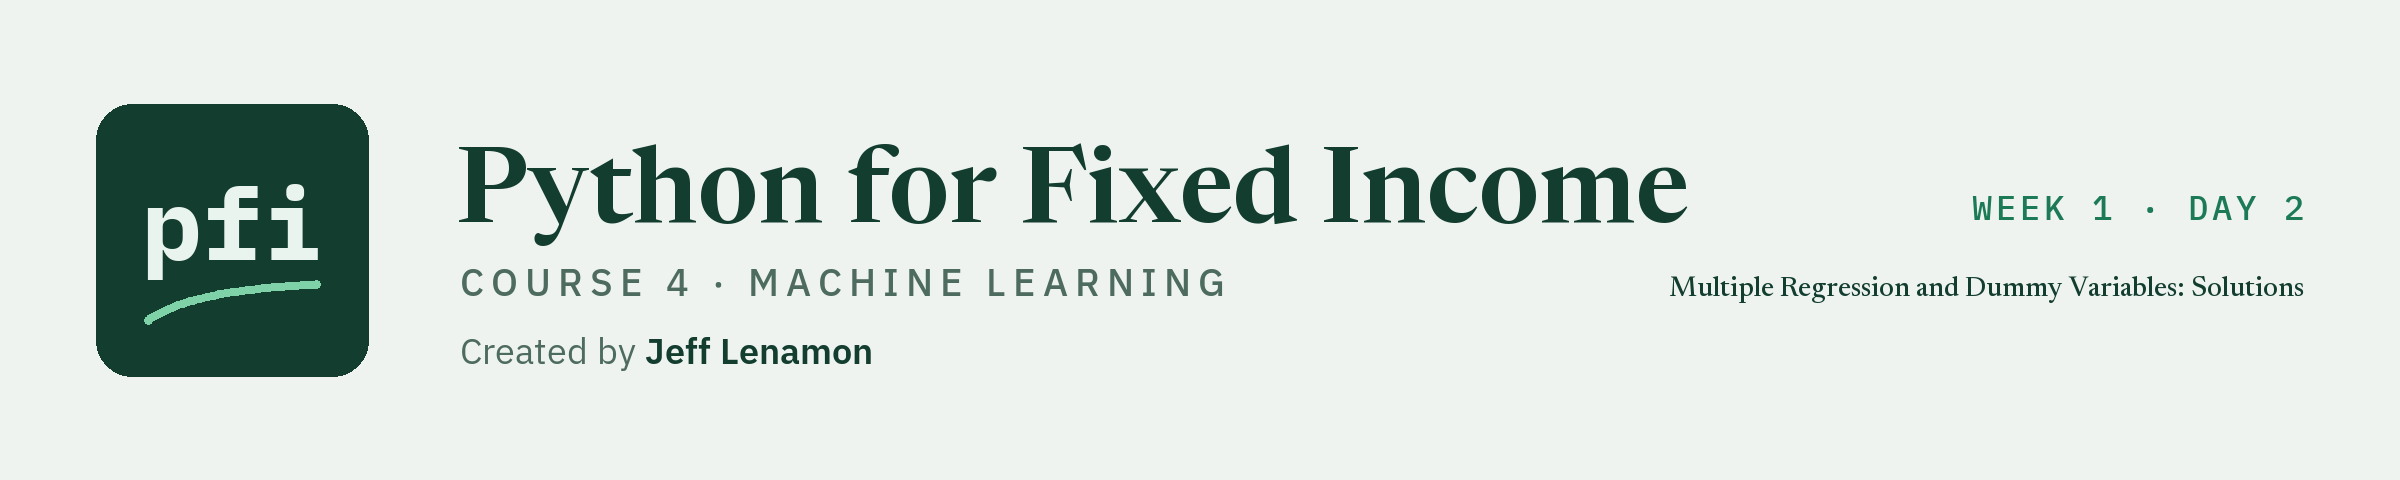

# Multiple Regression and Dummy Variables: Solutions

Week 1, Day 2. Worked answers to the exercises. Try each one yourself first.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day2/02_multiple_regression_and_dummy_variables_solutions.ipynb)

This notebook stands on its own. Its setup writes `mlkit.py` and `test_mlkit.py` as they stand at the end of today, so the exercises can be run without the lesson.

Q. Set up today's work folder.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_02_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_02_mhlmvotn, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the end of today.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies']


## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, makes the course split, builds section 2.3's rating dummies and duration, fits that model, and defines `check`, a small function that marks your answers.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score and grade
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
levels = ratings["rating"].tolist()

# the course split, then section 2.3's model: rating dummies (reference A) and duration, fitted on the training rows
train, test = train_test_split(bench, test_size=0.25, random_state=SEED)
y_train, y_test = train["oas"], test["oas"]
X_train = pd.concat([mlkit.rating_dummies(train["rating"], levels, reference="A"), train[["duration"]]], axis=1)
X_test = pd.concat([mlkit.rating_dummies(test["rating"], levels, reference="A"), test[["duration"]]], axis=1)
model = LinearRegression().fit(X_train, y_train)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Add each bond's amount outstanding, in billions (`amount_outstanding / 1e9`, a column named `amount_bn`), to section 2.3's features. Fit on the training rows and store the coefficient on `amount_bn` in bp per billion in **ex1_coef_bp_per_bn** and the test MAE in bp in **ex1_test_mae_bp**.

In [6]:
# section 2.3's features plus the amount outstanding in billions
X_train_amount = X_train.assign(amount_bn=train["amount_outstanding"] / 1e9)
X_test_amount = X_test.assign(amount_bn=test["amount_outstanding"] / 1e9)
model_amount = LinearRegression().fit(X_train_amount, y_train)

ex1_coef_bp_per_bn = pd.Series(model_amount.coef_, index=X_train_amount.columns)["amount_bn"]
ex1_test_mae_bp = mlkit.regression_metrics(y_test, model_amount.predict(X_test_amount))["mae"]
print(f"amount_bn: {ex1_coef_bp_per_bn:.2f} bp per billion; test MAE {ex1_test_mae_bp:.1f} bp "
      f"(without it: {mlkit.regression_metrics(y_test, model.predict(X_test))['mae']:.1f} bp)")

amount_bn: -1.25 bp per billion; test MAE 35.6 bp (without it: 35.5 bp)


* -1.25 bp per billion, and a test MAE of 35.6 bp against 35.5 bp without it. The generator does not use the amount outstanding, so whatever coefficient it gets here is noise in the training rows, as sector's was.

In [7]:
check("Exercise 1 the coefficient", ex1_coef_bp_per_bn, -1.2538686624324669)
check("Exercise 1 the test MAE", ex1_test_mae_bp, 35.618323970375705)

Exercise 1 the coefficient: correct
Exercise 1 the test MAE: correct


### Exercise 2

Q. Fit the same kind of model on the investment grade bonds only, with **BBB** as the reference level. Use only the investment grade levels from `ratings.csv`, split the investment grade bonds with the course's split (`test_size=0.25`, `random_state=SEED`), and use rating dummies and duration. Store the coefficient on `rating_AAA` in bp in **ex2_aaa_vs_bbb_bp** and the test MAE in bp in **ex2_test_mae_bp**.

In [8]:
# the investment grade levels, AAA to BBB-, and their bonds
ig_levels = ratings.loc[ratings["grade"] == "Investment Grade", "rating"].tolist()
investment_grade = bench[bench["grade"] == "Investment Grade"]
ig_train, ig_test = train_test_split(investment_grade, test_size=0.25, random_state=SEED)

def ig_features(frame):
    """Rating dummies with BBB as the reference, beside duration (years)."""
    return pd.concat([mlkit.rating_dummies(frame["rating"], ig_levels, reference="BBB"), frame[["duration"]]], axis=1)

model_ig = LinearRegression().fit(ig_features(ig_train), ig_train["oas"])
ex2_aaa_vs_bbb_bp = pd.Series(model_ig.coef_, index=ig_features(ig_train).columns)["rating_AAA"]
ex2_test_mae_bp = mlkit.regression_metrics(ig_test["oas"], model_ig.predict(ig_features(ig_test)))["mae"]
print(f"AAA against BBB: {ex2_aaa_vs_bbb_bp:.1f} bp; test MAE {ex2_test_mae_bp:.1f} bp on {len(ig_test)} bonds")

AAA against BBB: -102.8 bp; test MAE 20.9 bp on 135 bonds


* Holding duration fixed, a AAA bond's fitted spread is 102.8 bp below a BBB bond's in these rows. Same bonds, different reference, different coefficient: the number only means something beside the level it is measured from.

In [9]:
check("Exercise 2 AAA against BBB", ex2_aaa_vs_bbb_bp, -102.79290746432272)
check("Exercise 2 the test MAE", ex2_test_mae_bp, 20.924565657824637)

Exercise 2 AAA against BBB: correct
Exercise 2 the test MAE: correct


### Exercise 3

Q. Add a function to your module. `reference_level(columns, levels)` returns the rating level that has no `rating_<level>` column, the level every rating coefficient is measured from, and raises `ValueError` unless exactly one level is missing. Write the docstring first. Then add `test_reference_level`, which checks a hand case, the columns `pd.get_dummies(..., prefix="rating", drop_first=True)` makes for three ratings, and the error. Run pytest, reload the module, and store in **ex3_high_yield_reference** the reference of `pd.get_dummies(hy["rating"], prefix="rating", drop_first=True)`, where `hy` holds the high yield bonds and the levels are the high yield levels of `ratings.csv`.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [10]:
%%writefile -a mlkit.py


def reference_level(columns, levels: list[str]) -> str:
    """The rating level with no rating_<level> column: the reference every rating coefficient is measured from.

    Inputs: columns, the column names of a feature table (other columns, for example duration, are ignored);
    levels, every rating level. Output: the one level whose rating_<level> column is missing.
    Raises ValueError unless exactly one level has no column.
    """
    present = set(columns)
    # the levels whose column is missing
    missing = [level for level in levels if f"rating_{level}" not in present]
    if len(missing) != 1:
        raise ValueError(f"expected exactly one level without a column, found {missing}")
    return missing[0]

Appending to mlkit.py


In [11]:
%%writefile -a test_mlkit.py


def test_reference_level():
    levels = ["AAA", "A", "BBB"]
    assert mlkit.reference_level(["rating_AAA", "rating_BBB", "duration"], levels) == "A"
    # get_dummies with drop_first=True leaves out the level that sorts first as text
    quick = pd.get_dummies(pd.Series(["AAA", "A", "BBB"]), prefix="rating", drop_first=True)
    assert mlkit.reference_level(quick.columns, levels) == "A"
    with pytest.raises(ValueError):
        mlkit.reference_level(["rating_AAA", "rating_A", "rating_BBB"], levels)

Appending to test_mlkit.py


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...........                                                              [100%]
11 passed in 1.76s



In [13]:
# the file changed, so reload before calling the new function
importlib.reload(mlkit)
hy = bench[bench["grade"] == "High Yield"]
hy_levels = ratings.loc[ratings["grade"] == "High Yield", "rating"].tolist()
ex3_high_yield_reference = mlkit.reference_level(pd.get_dummies(hy["rating"], prefix="rating", drop_first=True).columns, hy_levels)
print(f"get_dummies(drop_first=True) on the high yield bonds measures every coefficient from {ex3_high_yield_reference}")

get_dummies(drop_first=True) on the high yield bonds measures every coefficient from B


* `11 passed`: today's 10 and the new one.
* B: the level that sorts first as text among the high yield ratings. A function that reads the reference from the columns turns a silent assumption into a check.

In [14]:
check("Exercise 3 the high yield reference", ex3_high_yield_reference, 'B')

Exercise 3 the high yield reference: correct


### Exercise 4: AI check

You ask an AI assistant for a function that fits rating dummies and duration and says what each rating coefficient is measured from, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit OAS (bp) on rating dummies and duration, and name the level every rating coefficient is measured from.

    Rating dummies: one column per rating level except the reference level, which the intercept stands for.
    The reference level is the course's, A, and the summary must name it: each rating coefficient is the
    fitted difference in bp from an A-rated bond of the same duration.
    Split: train_test_split(..., test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the coefficients as a Series indexed by column name, and the reference level as text.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, fits on the training rows, returns coefficients of the right size, and contains one bug.

* The bug: the comment says `drop_first=True` drops AAA, and the function reports AAA as the reference. `get_dummies` sorts the ratings as text, so it drops **A**. The coefficients are differences from an A-rated bond, but every sentence written from them would say "over AAA": the coefficient on `rating_AAA` itself, -49.0 bp, would be read as AAA's spread over AAA. The numbers are right and their label is wrong, which is the harder error to see.
* The fix, in the cell below: build the columns with `mlkit.rating_dummies`, naming the reference in the call, and return that same name.

In [15]:
def rating_effects(bonds):
    """Fit OAS (bp) on rating dummies and duration, and name the level every rating coefficient is measured from.

    Rating dummies: one column per rating level except the reference level, which the intercept stands for.
    The reference level is the course's, A, and the summary must name it: each rating coefficient is the
    fitted difference in bp from an A-rated bond of the same duration.
    Split: train_test_split(..., test_size=0.25, random_state=SEED); fit on the training rows only.
    Returns: the coefficients as a Series indexed by column name, and the reference level as text.
    """
    # the fix: name the reference in the call, from the levels in ratings.csv, and report that same level
    levels = pd.read_csv("ratings.csv")["rating"].tolist()
    reference = "A"
    X = pd.concat([mlkit.rating_dummies(bonds["rating"], levels, reference=reference), bonds[["duration"]]], axis=1)
    y = bonds["oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    model = LinearRegression().fit(X_train, y_train)
    return pd.Series(model.coef_, index=X.columns), reference

In [16]:
# the same test, with the reference read by the exercise 3 function
ai_coefficients, ai_reference = rating_effects(bench)
assert "rating_AAA" in ai_coefficients.index, "AAA has no column"
assert "rating_A" not in ai_coefficients.index, "A has a column"
assert mlkit.reference_level(ai_coefficients.index, levels) == ai_reference
print(f"rating_effects names its reference correctly: {ai_reference}")

rating_effects names its reference correctly: A


In [17]:
ex4_reference = rating_effects(bench)[1]
print(f"fixed: every rating coefficient is a difference from an {ex4_reference}-rated bond")

fixed: every rating coefficient is a difference from an A-rated bond


* The coefficients are the same numbers as before the fix; only the name of their reference changed, and now it is the right one. Keep the test: a reference level that is assumed rather than checked is the usual way a dummy model is misread.

In [18]:
check("Exercise 4 the fixed function's reference", ex4_reference, 'A')

Exercise 4 the fixed function's reference: correct


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```